# HDT 5: Árboles, Selección de Modelos y Bosques

**Ciencia de Datos, Sección A** · Asignada: martes 29 de septiembre · **Entrega: martes 6 de octubre, 23:59**

**Nombre:** _Juan David Contreras_

Completar las celdas marcadas con `# ¿Qué va aquí?`. Cada ejercicio incluye una verificación comentada: descomentar para comprobar el resultado. Antes de entregar: **Kernel → Restart & Run All** (un notebook que no corre de arriba a abajo pierde 0.5 pts).

AI: resolver sin AI. Si se usó para entender un concepto, anotarlo en la bitácora del final (no penaliza).

## Setup

Dependencias: `pip install numpy pandas matplotlib scikit-learn`. Todo es determinista (semillas fijas y split fijo): las verificaciones son exactas.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

AZUL, ROJO, GRIS, LINEA = "#3A6EA5", "#B04A2E", "#75808E", "#E0E4EA"

def eje_limpio(ax):
    ax.grid(color=LINEA, lw=0.6, alpha=0.7)
    ax.spines[["top", "right"]].set_visible(False)

## Los datos

Un gimnasio quiere saber qué socios van a darse de baja. Historial de 1,000 socios: `visitas` (al mes), `meses` (antigüedad como socio), `cuota` (quetzales al mes) y `se_va` (1 = no renovó). El mismo tipo de problema que la mora del banco de las sesiones 15 a 17, con otro negocio.

La celda genera los datos completa; no hay nada que llenar aquí.

In [2]:
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(5)
n = 1000
visitas = np.minimum(rng.poisson(8, n), 30)
meses = rng.integers(1, 49, n)
cuota = rng.normal(400, 90, n).clip(200, 700).round(0)

riesgo = (-2.4 + 1.6 * (visitas <= 5) + 1.1 * (meses <= 12)
          + 0.9 * (cuota >= 480) + 1.1 * ((visitas <= 5) & (meses <= 12)))
se_va = (rng.random(n) < 1 / (1 + np.exp(-riesgo))).astype(int)

df = pd.DataFrame({"visitas": visitas, "meses": meses, "cuota": cuota, "se_va": se_va})
columnas = ["visitas", "meses", "cuota"]
X_train, X_test, y_train, y_test = train_test_split(
    df[columnas], df["se_va"], test_size=0.3, random_state=42)

print("socios:", len(df), "| fracción que se va:", df["se_va"].mean().round(3))
print("entrenamiento:", len(X_train), "| examen:", len(X_test))
df.head()

socios: 1000 | fracción que se va: 0.187
entrenamiento: 700 | examen: 300


,visitas,meses,cuota,se_va
0,7,25,502.0,0
1,10,6,373.0,0
2,6,44,543.0,0
3,5,39,489.0,1
4,8,3,490.0,1


## Parte A · Un árbol (0.5 pt)

El modelo de preguntas de la sesión 15: elegir el corte que deja los grupos menos mezclados, y la profundidad como perilla.

### Ejercicio 1 (0.15): la mezcla a mano

Con la función `mezcla` de clase, sobre el **entrenamiento** (700 socios, 132 se van): (a) la mezcla sin cortar nada; (b) la mezcla promedio ponderada del corte `visitas <= 5`; (c) la del corte `meses <= 12`. ¿Cuál de los dos cortes gana, y coincide con la primera pregunta que elige un árbol de profundidad 1?

In [3]:
def mezcla(se_van, se_quedan):
    p = se_van / (se_van + se_quedan)
    return 1 - p**2 - (1 - p)**2

def mezcla_del_corte(columna, corte):
    lado = X_train[columna] <= corte
    total = len(X_train)
    promedio = 0
    for mascara in [lado, ~lado]:
        se_van = y_train[mascara].sum()
        se_quedan = (mascara.sum()) - se_van
        m = mezcla(se_van, se_quedan)
        print(f"  {columna} {'<=' if mascara is lado else '>'} {corte}: {se_van} se van / {se_quedan} se quedan, mezcla {m:.3f}")
        promedio += m * mascara.sum() / total
    return promedio

m_total = mezcla(y_train.sum(), (1 - y_train).sum())
m_visitas = mezcla_del_corte("visitas", 5)
m_meses = mezcla_del_corte("meses", 12)

print(f"sin cortar:       {m_total:.3f}")
print(f"visitas <= 5:     {m_visitas:.3f}")
print(f"meses <= 12:      {m_meses:.3f}")

# Respuesta: gana visitas <= 5 (0.252 contra 0.290): deja los grupos menos mezclados.
# Se comprueba abajo que es justo la pregunta que elige un árbol de profundidad 1.
from sklearn.tree import DecisionTreeClassifier, export_text
arbol1 = DecisionTreeClassifier(max_depth=1, random_state=0).fit(X_train, y_train)
print(export_text(arbol1, feature_names=columnas))

# Verificación (descomentar):
assert round(m_total, 3) == 0.306
assert round(m_visitas, 3) == 0.252
assert round(m_meses, 3) == 0.290

  visitas <= 5: 72 se van / 67 se quedan, mezcla 0.499
  visitas > 5: 60 se van / 501 se quedan, mezcla 0.191
  meses <= 12: 65 se van / 129 se quedan, mezcla 0.446
  meses > 12: 67 se van / 439 se quedan, mezcla 0.230
sin cortar:       0.306
visitas <= 5:     0.252
meses <= 12:      0.290
|--- visitas <= 5.50
|   |--- class: 1
|--- visitas >  5.50
|   |--- class: 0



### Ejercicio 2 (0.20): la profundidad es la perilla

Para cada profundidad en [1, 2, 3, 4, 6, 8, 12]: entrenar un árbol (`random_state=0`) y guardar aciertos en entrenamiento y en examen. Graficar las dos curvas (AZUL entrenamiento, ROJO examen) con `eje_limpio`. Responder en un comentario: ¿qué profundidad elegirían y por qué?

profundidad  1: entrenamiento 0.819 | examen 0.830
profundidad  2: entrenamiento 0.850 | examen 0.850
profundidad  3: entrenamiento 0.860 | examen 0.860
profundidad  4: entrenamiento 0.870 | examen 0.840
profundidad  6: entrenamiento 0.896 | examen 0.830
profundidad  8: entrenamiento 0.934 | examen 0.807
profundidad 12: entrenamiento 0.991 | examen 0.767


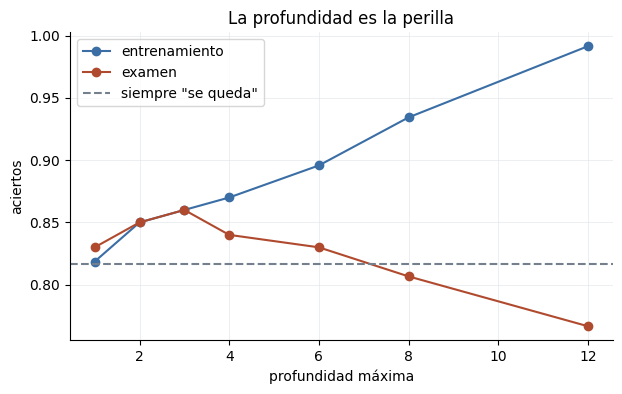

In [4]:
from sklearn.tree import DecisionTreeClassifier

profundidades = [1, 2, 3, 4, 6, 8, 12]
acc_train = []
acc_test = []

for d in profundidades:
    arbol = DecisionTreeClassifier(max_depth=d, random_state=0).fit(X_train, y_train)
    acc_train.append(arbol.score(X_train, y_train))
    acc_test.append(arbol.score(X_test, y_test))
    print(f"profundidad {d:>2}: entrenamiento {acc_train[-1]:.3f} | examen {acc_test[-1]:.3f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(profundidades, acc_train, "o-", color=AZUL, label="entrenamiento")
ax.plot(profundidades, acc_test, "o-", color=ROJO, label="examen")
ax.axhline(1 - y_test.mean(), color=GRIS, ls="--", label='siempre "se queda"')
ax.set_xlabel("profundidad máxima")
ax.set_ylabel("aciertos")
ax.set_title("La profundidad es la perilla")
ax.legend()
eje_limpio(ax)
plt.show()

# Respuesta: profundidad 3. El examen llega a su máximo (0.86) ahí y ya no mejora con más preguntas,
# mientras el entrenamiento sigue subiendo hasta 0.991 con profundidad 12 y el examen cae a 0.767:
# a partir de ahí el árbol memoriza a los socios. Entre empates, el árbol más simple (3 niveles).

# Verificación (descomentar):
assert round(acc_test[2], 2) == 0.86      # profundidad 3
assert round(acc_train[6], 3) == 0.991 and round(acc_test[6], 3) == 0.767

### Ejercicio 3 (0.15): un árbol solo es inestable

Entrenar 25 árboles **sin límite de profundidad**, cada uno con 350 socios del entrenamiento elegidos al azar (`np.random.default_rng(s).choice(len(X_train), 350, replace=False)` con `s` de 0 a 24), y guardar sus aciertos en el examen. Reportar el mínimo y el máximo. De paso: imprimir la primera pregunta de los árboles con `s` de 0 a 3 (profundidad 2) y observar que esa sí es estable.

In [5]:
from sklearn.tree import export_text

aciertos = []
for s in range(25):
    idx = np.random.default_rng(s).choice(len(X_train), 350, replace=False)
    arbol = DecisionTreeClassifier(random_state=0).fit(X_train.iloc[idx], y_train.iloc[idx])
    aciertos.append(arbol.score(X_test, y_test))

print(f"aciertos en examen: mínimo {min(aciertos):.3f} | máximo {max(aciertos):.3f}")

print("\nPrimera pregunta (profundidad 2) con s de 0 a 3:")
for s in range(4):
    idx = np.random.default_rng(s).choice(len(X_train), 350, replace=False)
    arbol2 = DecisionTreeClassifier(max_depth=2, random_state=0).fit(X_train.iloc[idx], y_train.iloc[idx])
    primera = export_text(arbol2, feature_names=columnas).splitlines()[0].strip("| -")
    print(f"  s={s}: {primera}")

# Un árbol sin límite cambia varios puntos según qué 350 socios vio, pero la primera pregunta sí es estable.

# Verificación (descomentar):
assert round(min(aciertos), 3) == 0.73
assert round(max(aciertos), 3) == 0.8

aciertos en examen: mínimo 0.730 | máximo 0.800

Primera pregunta (profundidad 2) con s de 0 a 3:
  s=0: visitas <= 5.50
  s=1: visitas <= 5.50
  s=2: visitas <= 5.50
  s=3: visitas <= 5.50


## Parte B · Elegir sin trampa (0.5 pt)

La sesión 16 en tres pasos: comparar candidatos con validación cruzada, afinar perillas con búsqueda, y tocar el examen una sola vez.

### Ejercicio 4 (0.20): tres candidatos, el mismo procedimiento

Comparar con validación cruzada estratificada de 5 pliegues (`StratifiedKFold(n_splits=5, shuffle=True, random_state=7)`) sobre el **entrenamiento**: logística (con escala, en Pipeline), árbol (`max_depth=4`) y kNN (con escala, `n_neighbors=15`). Imprimir promedio y desviación de cada uno. ¿Quién gana?

In [6]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)
candidatos = {
    "logística": make_pipeline(StandardScaler(), LogisticRegression()),
    "árbol": DecisionTreeClassifier(max_depth=4, random_state=0),
    "kNN": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=15)),
}

promedios = {}
for nombre, modelo in candidatos.items():
    puntajes = cross_val_score(modelo, X_train, y_train, cv=cv)
    promedios[nombre] = puntajes.mean()
    print(f"{nombre:<10} promedio {puntajes.mean():.3f} | desv. {puntajes.std():.3f} | pliegues {np.round(puntajes, 3)}")

print("\nGana:", max(promedios, key=promedios.get))
# Gana el árbol (0.846): los datos tienen forma de regla (poca visita y poca antigüedad),
# y la logística (una sola recta) y kNN no capturan tan bien esa esquina.

# Verificación (descomentar):
assert round(promedios["árbol"], 3) == 0.846
assert promedios["árbol"] == max(promedios.values())

logística  promedio 0.827 | desv. 0.019 | pliegues [0.814 0.814 0.821 0.864 0.821]
árbol      promedio 0.846 | desv. 0.012 | pliegues [0.85  0.864 0.829 0.85  0.836]
kNN        promedio 0.827 | desv. 0.013 | pliegues [0.843 0.814 0.814 0.843 0.821]

Gana: árbol


### Ejercicio 5 (0.15): afinar las perillas del ganador

`GridSearchCV` sobre el árbol con `max_depth` en [2, 3, 4, 6] y `min_samples_leaf` en [5, 20, 50], usando el mismo `cv`. ¿Cuántas combinaciones probó? Imprimir la mejor y su puntaje.

In [7]:
from sklearn.model_selection import GridSearchCV

malla = {"max_depth": [2, 3, 4, 6], "min_samples_leaf": [5, 20, 50]}
busqueda = GridSearchCV(DecisionTreeClassifier(random_state=0), malla, cv=cv)
busqueda.fit(X_train, y_train)

print("combinaciones probadas:", len(busqueda.cv_results_["params"]), "(4 x 3), cada una con 5 simulacros =", len(busqueda.cv_results_["params"]) * 5, "árboles")
print("mejor combinación:", busqueda.best_params_)
print(f"mejor puntaje de simulacros: {busqueda.best_score_:.3f}")

# Verificación (descomentar):
assert busqueda.best_params_ == {"max_depth": 3, "min_samples_leaf": 20}
assert round(busqueda.best_score_, 3) == 0.856

combinaciones probadas: 12 (4 x 3), cada una con 5 simulacros = 60 árboles
mejor combinación: {'max_depth': 3, 'min_samples_leaf': 20}
mejor puntaje de simulacros: 0.856


### Ejercicio 6 (0.15): el examen se usa una vez

Tomar `busqueda.best_estimator_` (ya viene entrenado con los 700) y evaluarlo en el examen. Responder en un comentario: ¿por qué este número puede ser distinto del 0.856 anterior, y por qué no se vale seguir probando modelos después de verlo?

In [8]:
examen_final = busqueda.best_estimator_.score(X_test, y_test)
print(f"examen (usado una sola vez): {examen_final:.3f}")

# Respuesta: el 0.856 es el promedio de 5 simulacros dentro del entrenamiento (700 socios, cada simulacro
# de 140) y sirvió para ELEGIR; el 0.86 sale de 300 socios que el modelo nunca vio. Son muestras distintas y
# pequeñas (un punto son ~3 socios), así que difieren por azar. Después de ver el examen no se vale seguir
# probando modelos: cada ajuste que hagamos mirándolo lo convierte en simulacro y el número ya no es honesto
# (sería elegir con las respuestas a la vista).

# Verificación (descomentar):
assert round(examen_final, 3) == 0.86

examen (usado una sola vez): 0.860


## Parte C · El bosque (0.8 pt)

La sesión 17: si un árbol baila, que voten muchos. Bootstrap, bagging a mano, OOB e importancias.

### Ejercicio 7 (0.20): bagging a mano

Para B en [1, 5, 25, 100]: entrenar B árboles sin límite, cada uno con una muestra bootstrap (`np.random.default_rng(b).integers(0, len(X_train), len(X_train))` con `b` de 0 a B-1), sumar sus votos sobre el examen y clasificar por mayoría (`votos / B >= 0.5`). Guardar los aciertos en `aciertos_bagging` y graficar contra B.

B =   1: aciertos en examen 0.767
B =   5: aciertos en examen 0.787
B =  25: aciertos en examen 0.820
B = 100: aciertos en examen 0.823


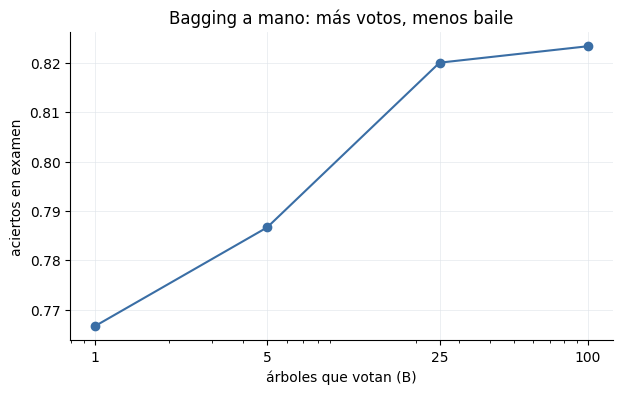

In [9]:
cantidades = [1, 5, 25, 100]
aciertos_bagging = []

for B in cantidades:
    votos = np.zeros(len(X_test))
    for b in range(B):
        idx = np.random.default_rng(b).integers(0, len(X_train), len(X_train))   # bootstrap
        arbol = DecisionTreeClassifier(random_state=0).fit(X_train.iloc[idx], y_train.iloc[idx])
        votos += arbol.predict(X_test)
    pred = (votos / B >= 0.5).astype(int)
    aciertos_bagging.append((pred == y_test.values).mean())
    print(f"B = {B:>3}: aciertos en examen {aciertos_bagging[-1]:.3f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(cantidades, aciertos_bagging, "o-", color=AZUL)
ax.set_xscale("log")
ax.set_xticks(cantidades)
ax.set_xticklabels(cantidades)
ax.set_xlabel("árboles que votan (B)")
ax.set_ylabel("aciertos en examen")
ax.set_title("Bagging a mano: más votos, menos baile")
eje_limpio(ax)
plt.show()

# Verificación (descomentar):
assert [round(a, 3) for a in aciertos_bagging] == [0.767, 0.787, 0.82, 0.823]

### Ejercicio 8 (0.20): las perillas del bosque, medidas con OOB

Para `min_samples_leaf` en [1, 5, 10, 20, 50]: RandomForest de 300 árboles con `oob_score=True` (`random_state=0, n_jobs=-1`), guardar el OOB de cada uno en el diccionario `oobs`. Elegir el mejor y reportar su examen. Todo sin usar el examen para elegir: para eso está el OOB.

In [11]:
from sklearn.ensemble import RandomForestClassifier

oobs = {}
for msl in [1, 5, 10, 20, 50]:
    rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=msl, oob_score=True,
                                random_state=0, n_jobs=-1).fit(X_train, y_train)
    oobs[msl] = rf.oob_score_
    print(f"min_samples_leaf = {msl:>2}: OOB {oobs[msl]:.3f}")

mejor_msl = max(oobs, key=oobs.get)     
bosque = RandomForestClassifier(n_estimators=300, min_samples_leaf=mejor_msl,
                                random_state=0, n_jobs=-1).fit(X_train, y_train)
examen_bosque = bosque.score(X_test, y_test)   
print(f"\nmejor min_samples_leaf: {mejor_msl} (OOB {oobs[mejor_msl]:.3f}) | examen {examen_bosque:.3f}")

# Verificación (descomentar):
assert mejor_msl == 5 and round(oobs[5], 3) == 0.857
assert round(examen_bosque, 3) == 0.86

min_samples_leaf =  1: OOB 0.831
min_samples_leaf =  5: OOB 0.857
min_samples_leaf = 10: OOB 0.856
min_samples_leaf = 20: OOB 0.846
min_samples_leaf = 50: OOB 0.811

mejor min_samples_leaf: 5 (OOB 0.857) | examen 0.860


### Ejercicio 9 (0.20): la señal arriba, el ruido abajo

Agregar al entrenamiento una columna `ruido` de puro azar (`np.random.default_rng(9).normal(0, 1, len(X_train))`), entrenar un bosque (300 árboles, `min_samples_leaf=20`, `random_state=0`) y ordenar las importancias de mayor a menor. ¿Dónde quedó el ruido?

In [12]:
X_train_ruido = X_train.copy()
X_train_ruido["ruido"] = np.random.default_rng(9).normal(0, 1, len(X_train))

rf_ruido = RandomForestClassifier(n_estimators=300, min_samples_leaf=20,
                                  random_state=0, n_jobs=-1).fit(X_train_ruido, y_train)
importancias = pd.Series(rf_ruido.feature_importances_, index=X_train_ruido.columns).sort_values(ascending=False)
print(importancias.round(3))

# El ruido quedó en último lugar (0.091). Las columnas con señal (visitas, meses, cuota) lo superan.
# Ojo: no es 0, porque un árbol siempre encuentra algún corte "útil" por casualidad en el entrenamiento.

# Verificación (descomentar):
assert importancias.index[0] == "visitas" and importancias.index[-1] == "ruido"
assert round(importancias["ruido"], 3) == 0.091

visitas    0.562
meses      0.236
cuota      0.111
ruido      0.091
dtype: float64


### Ejercicio 10 (0.20): un árbol contra un bosque, diez veces

Repetir 10 veces (repartos `train_test_split` con `random_state` de 0 a 9): entrenar un árbol sin límite y un bosque (200 árboles, `min_samples_leaf=20`) y guardar los aciertos de examen de cada uno. Reportar mínimo y máximo de cada modelo. ¿Qué se observa?

In [ ]:
arbol_res = []
bosque_res = []

for s in range(10):
    Xa, Xb, ya, yb = train_test_split(df[columnas], df["se_va"], test_size=0.3, random_state=s)
    arbol = DecisionTreeClassifier(random_state=0).fit(Xa, ya)
    bosque = RandomForestClassifier(n_estimators=200, min_samples_leaf=20, random_state=0, n_jobs=-1).fit(Xa, ya)
    arbol_res.append(arbol.score(Xb, yb))
    bosque_res.append(bosque.score(Xb, yb))

print(f"árbol:  mínimo {min(arbol_res):.3f} | máximo {max(arbol_res):.3f} | rango {max(arbol_res)-min(arbol_res):.3f}")
print(f"bosque: mínimo {min(bosque_res):.3f} | máximo {max(bosque_res):.3f} | rango {max(bosque_res)-min(bosque_res):.3f}")

# Respuesta: el bosque acierta más en todos los repartos (su peor caso es 0.82 y ya supera incluso al mejor
# del árbol, 0.80) y su resultado se mueve menos que el del árbol, que baila entre 0.71 y 0.80. Votar promedia
# el baile de cada árbol.

# Verificación (descomentar):
assert round(min(arbol_res), 3) == 0.71 and round(max(arbol_res), 3) == 0.8
assert round(min(bosque_res), 3) == 0.82 and round(max(bosque_res), 3) == 0.88

árbol:  mínimo 0.710 | máximo 0.800 | rango 0.090
bosque: mínimo 0.820 | máximo 0.880 | rango 0.060


## Parte D · Criterio (0.2 pt)

### Ejercicio 11 (0.20)

Dos preguntas, 2-3 líneas cada una, **citando los números obtenidos**:

**(a)** El 0.856 del ejercicio 5 y el 0.86 del ejercicio 6 se parecen, pero no son intercambiables. Explicar qué es cada número, cuál se reporta a gerencia y por qué el examen se usa una sola vez.

**(b)** El gimnasio va a desplegar un modelo para llamar a socios en riesgo. Con los resultados de los ejercicios 8 a 10, ¿árbol o bosque? Dar el argumento con números, y mencionar qué se pierde a cambio.

**Respuesta (a):** El 0.856 es el promedio de los cinco simulacros de la validación cruzada dentro del entrenamiento (700 socios): sirvió para comparar candidatos y elegir las perillas (max_depth=3, min_samples_leaf=20). El 0.86 es el examen: 300 socios que el modelo nunca vio, medidos una sola vez con el modelo ya elegido. A gerencia se reporta el 0.86, porque es la estimación que no participó en ninguna decisión. Si el examen se usara para elegir y volver a probar, dejaría de ser examen: el número quedaría inflado por haber visto las respuestas. Además un punto son solo ~3 socios, así que 0.856 y 0.86 son prácticamente lo mismo.

**Respuesta (b):** Bosque. En los diez repartos el árbol sin límite oscila entre 0.71 y 0.80 (rango de 9 puntos) y el bosque entre 0.82 y 0.88 (rango de 6), mientras que su peor reparto supera al peor del árbol por 11 puntos e incluso supera al mejor del árbol (0.80). El bagging a mano también lo muestra: de 0.767 con 1 árbol a 0.823 con 100. Con el OOB (0.857) se eligió min_samples_leaf=5 sin tocar el examen, y dio 0.86 en examen. A cambio se pierde interpretabilidad: el árbol de profundidad 3 (0.86 en examen) se lee en voz alta en un minuto, mientras que 300 árboles votando no; también cuesta más entrenar y predecir. Si la gerencia necesita explicar las reglas, el árbol pequeño y regularizado empata en examen; si se quiere estabilidad ante datos nuevos, el bosque.

## Bitácora de AI (opcional, no penaliza)

Si se usó AI para entender algún concepto, anotar aquí qué se preguntó y qué se entendió. Si no se usó, escribir "No se usó".

- Un uso que se le dio a la AI fue para la presentación a la hora de imprimir los resultados. Que este organizado por tablas, relacionar el numero con lo que se esta preguntamdo, redondear decimales, etc. Uso de AI en la presentación de las respuestas para que este organizadas y se entiendan. 

- Se utilizó como apoyo para ordenar y realizar la gráficas, para asi entender bien como armarlas de forma correcta. Tener claras las partes de cada una y que significaba cada una para representar bien el dato. 

- Se consultó la formas de realizar ciertos calculos. Tanto formulas específicas que no estaban explicitamente en la presentación, asi como algunas formas de calcular de manera sencilla los datos. Básicamente facilitar el transpasar la formula y el calculo a el lenguaje de programación. Se tomaron las funciones de las presentaciones y se utilizo AI para entender bien como armarlas y adaptarlas a estos ejercicios. 